In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
# from numpy import infinity
import mapclassify
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib .patches import Patch, Rectangle
from shapely.geometry import Point
from shapely.geometry import LineString

commute21 = pd.read_csv(r"../data/sodb_2021_dochadzka_denne_lm_rk.csv", encoding="windows-1250")
commute11 = pd.read_csv(r"../data/dochadzka_zamestnanie_sodb_2011.csv", sep=";")
commute01 = pd.read_csv(r"../data/dochadzka_zamestnanie_sodb_2001.csv", sep=";")

obce = gpd.read_file(r"../data/liptov_obce.csv", encoding = "windows-1250")
map2 = gpd.read_file(r"../data/geo/liptov.shp")
okresy = gpd.read_file(r"../data/geo/liptov_okresy.shp")
lipt_colors = pd.read_csv(r"../data/colors.csv", sep=";")
map2.drop(columns = ["DOW", "FACC", "IDN3", "NM3", "IDN2", "NM2", "NUTS1", "NUTS1_CODE", "NUTS2", "NUTS2_CODE", "NUTS3", "NUTS3_CODE", "LAU1", "LAU1_CODE", "LAU2", "LAU2_CODE", "VYMERA", "Shape_Area", "Shape_Leng"], inplace = True)
commute11 = (commute11).rename(columns = {"obecA": "obecA", "obecB": "obecB", "POCET": "pocet11"})
commute01 = (commute01).rename(columns = {"Obec trvaleho pobytu": "obecA", "Miesto pracoviska (obec)": "obecB", "POCET": "pocet01"})

commute21[["obecA", "obecB"]] = commute21[["obecA", "obecB"]].astype(str)
commute21["pocet"] = commute21["pocet"].astype(int)
commute11[["obecA", "obecB"]] = commute11[["obecA", "obecB"]].astype(str)
commute11["pocet11"] = commute11["pocet11"].astype(int)
commute01[["obecA", "obecB"]] = commute01[["obecA", "obecB"]].astype(str)
commute01["pocet01"] = commute01["pocet01"].astype(int)


lipt_colors["obec_id"] = lipt_colors["obec_id"].astype(str)
map2["IDN4"] = map2["IDN4"].astype(str)
obce["kod"] = obce["kod"].astype(str)
obce["symbol"] = obce["kod"].apply(lambda code: "o" if (code != "510262") | (code != "510998") else "*")
unique_obce = map2["IDN4"].apply(str).tolist()
print(commute21)
commute11 = commute11[commute11["Periodicita dochadzky"] == 1]
commute11 = commute11[commute11["obecA"].isin(unique_obce) & commute11["obecB"].isin(unique_obce)]
commute01 = commute01[commute01["Periodicita dochadzky"] == 1]
commute01 = commute01[commute01["obecA"].isin(unique_obce) & commute01["obecB"].isin(unique_obce)]

obce_gdf = gpd.GeoDataFrame(
    obce,
    geometry=[Point(xy) for xy in zip(obce["x"], obce["y"])],
    crs="EPSG:5514"
)

      Unnamed: 0   obecA   obecB  pocet  okresA  okresB      obecA_nazov  \
0              1  507300  507300     18  SK0318  SK0318        Ivachnová   
1              2  507300  507407      1  SK0318  SK0318        Ivachnová   
2              3  507300  510262     10  SK0318  SK0315        Ivachnová   
3              4  507300  510301      6  SK0318  SK0318        Ivachnová   
4              5  507300  510386      1  SK0318  SK0315        Ivachnová   
...          ...     ...     ...    ...     ...     ...              ...   
1160        1161  580287  511111      3  SK0315  SK0315  Liptovský Peter   
1161        1162  580287  511170      1  SK0315  SK0315  Liptovský Peter   
1162        1163  580287  511196      3  SK0315  SK0315  Liptovský Peter   
1163        1164  580287  558281      7  SK0315  SK0315  Liptovský Peter   
1164        1165  580287  580287     11  SK0315  SK0315  Liptovský Peter   

            obecB_nazov  
0             Ivachnová  
1                 Turík  
2     Lip

In [2]:
all21 = (
    commute21
    .groupby("obecB", group_keys = False)["pocet"]
    .sum()
)
outer21 = (
    commute21[commute21["obecA"] != commute21["obecB"]]
    .groupby("obecB", group_keys=False)["pocet"]
    .sum()
)
inter21 = (
    commute21[commute21["obecA"] == commute21["obecB"]]
    .groupby("obecB", group_keys=False)["pocet"]
    .sum()
)

all21_df = all21.reset_index().rename(columns = {"pocet": "spolu21"})
inter21_df = inter21.reset_index().rename(columns = {"pocet": "v_obci21"})
outer21_df = outer21.reset_index().rename(columns = {"pocet": "mimo_obce21"})

table21 = all21_df.merge(
    inter21_df.merge(
    outer21_df,
    on = "obecB",
    how = "left"
), on = "obecB", how = "left").fillna(0)
table21["mimo_percent21"] = (table21["mimo_obce21"]/table21["spolu21"]*100).round(1)
table21["vnutri_percent21"] = (table21["v_obci21"]/table21["spolu21"]*100).round(1)
print(table21)

     obecB  spolu21  v_obci21  mimo_obce21  mimo_percent21  vnutri_percent21
0   507300       82      18.0         64.0            78.0              22.0
1   507393        3       2.0          1.0            33.3              66.7
2   507407        7       5.0          2.0            28.6              71.4
3   510262     9277    5181.0       4096.0            44.2              55.8
4   510271       11       6.0          5.0            45.5              54.5
..     ...      ...       ...          ...             ...               ...
75  511188        6       2.0          4.0            66.7              33.3
76  511196      483      51.0        432.0            89.4              10.6
77  511200       21      10.0         11.0            52.4              47.6
78  558281      142      26.0        116.0            81.7              18.3
79  580287       23      11.0         12.0            52.2              47.8

[80 rows x 6 columns]


In [3]:
all11 = (
    commute11
    .groupby("obecB", group_keys = False)["pocet11"]
    .sum()
)
outer11 = (
    commute11[commute11["obecA"] != commute11["obecB"]]
    .groupby("obecB", group_keys=False)["pocet11"]
    .sum()
)
inter11 = (
    commute11[commute11["obecA"] == commute11["obecB"]]
    .groupby("obecB", group_keys=False)["pocet11"]
    .sum()
)

all11_df = all11.reset_index().rename(columns = {"pocet11": "spolu11"})
inter11_df = inter11.reset_index().rename(columns = {"pocet11": "v_obci11"})
outer11_df = outer11.reset_index().rename(columns = {"pocet11": "mimo_obce11"})

table11 = all11_df.merge(
    inter11_df.merge(
    outer11_df,
    on = "obecB",
    how = "left"
), on = "obecB", how = "left").fillna(0)
table11["mimo_percent11"] = (table11["mimo_obce11"]/table11["spolu11"]*100).round(1)
table11["vnutri_percent11"] = (table11["v_obci11"]/table11["spolu11"]*100).round(1)
print(table11)

     obecB  spolu11  v_obci11  mimo_obce11  mimo_percent11  vnutri_percent11
0   507300       32      16.0         16.0            50.0              50.0
1   507393       10       8.0          2.0            20.0              80.0
2   507407        7       4.0          3.0            42.9              57.1
3   510262    10740    6513.0       4227.0            39.4              60.6
4   510271       30       8.0         22.0            73.3              26.7
..     ...      ...       ...          ...             ...               ...
76  511196      459      85.0        374.0            81.5              18.5
77  511200       35      17.0         18.0            51.4              48.6
78  556807        4       4.0          0.0             0.0             100.0
79  558281      196      48.0        148.0            75.5              24.5
80  580287       53      41.0         12.0            22.6              77.4

[81 rows x 6 columns]


In [4]:
all01 = (
    commute01
    .groupby("obecB", group_keys = False)["pocet01"]
    .sum()
)
outer01 = (
    commute01[commute01["obecA"] != commute01["obecB"]]
    .groupby("obecB", group_keys=False)["pocet01"]
    .sum()
)
inter01 = (
    commute01[commute01["obecA"] == commute01["obecB"]]
    .groupby("obecB", group_keys=False)["pocet01"]
    .sum()
)

all01_df = all01.reset_index().rename(columns = {"pocet01": "spolu01"})
inter01_df = inter01.reset_index().rename(columns = {"pocet01": "v_obci01"})
outer01_df = outer01.reset_index().rename(columns = {"pocet01": "mimo_obce01"})

table01 = all01_df.merge(
    inter01_df.merge(
    outer01_df,
    on = "obecB",
    how = "left"
), on = "obecB", how = "left").fillna(0)
table01["mimo_percent01"] = (table01["mimo_obce01"]/table01["spolu01"]*100).round(1)
table01["vnutri_percent01"] = (table01["v_obci01"]/table01["spolu01"]*100).round(1)
# print(commute01[commute01["obecB"] == "510840"])
# print(outer01_df[outer01_df["obecB"] == "510840"])
print(table01[table01["obecB"] == "510840"])

     obecB  spolu01  v_obci01  mimo_obce01  mimo_percent01  vnutri_percent01
48  510840       12      12.0          0.0             0.0             100.0


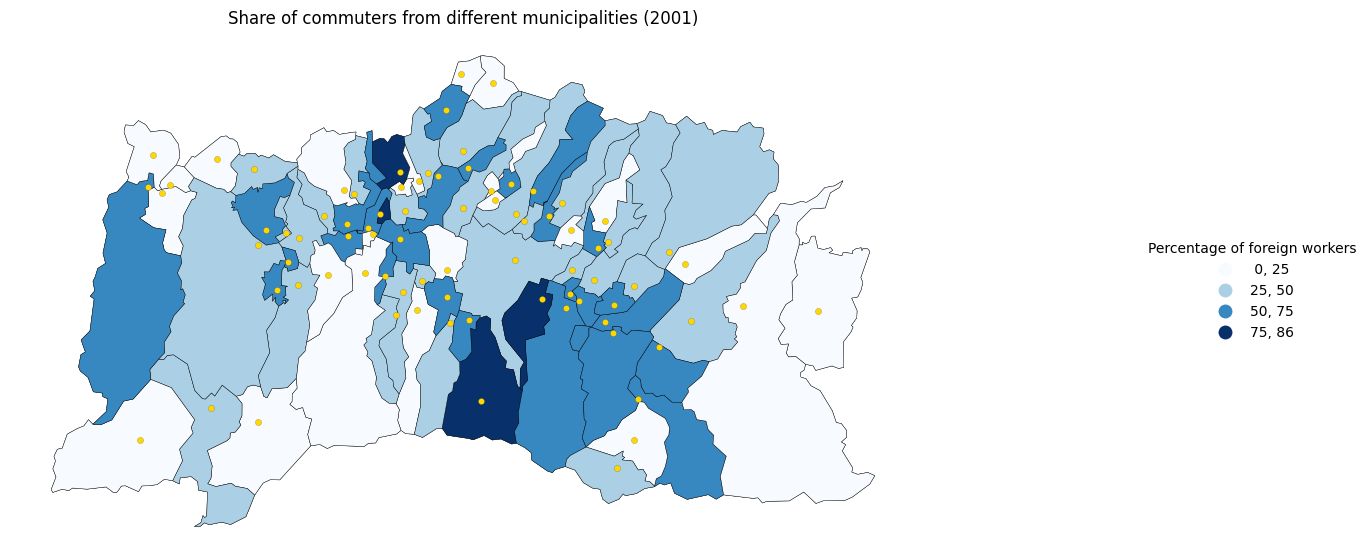

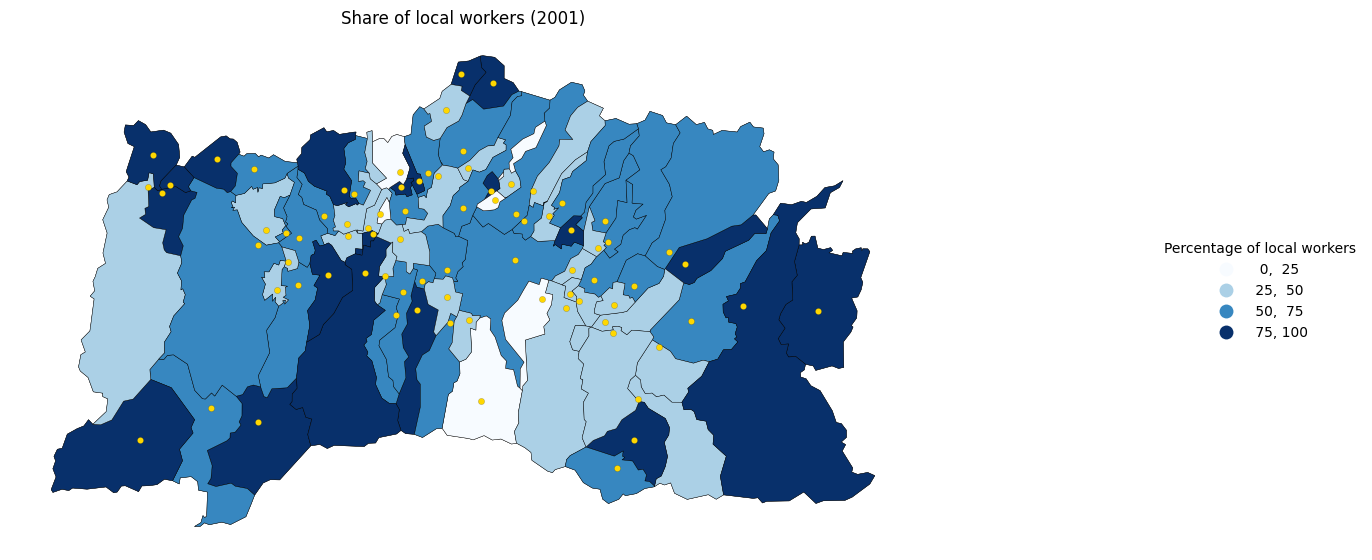

In [5]:
# -------------------------------------------------Share of foreign workers--------------------------------------------------------------

tablemap01 = map2.merge(
    table01,
    left_on = "IDN4",
    right_on = "obecB",
    how = "left"
)

independence_bins = [25, 50, 75]
plt.figure(figsize = (11.69, 8.27))
map2.plot(
    ax = plt.gca(),
    color = "lightgray",
    edgecolor = "black",
    linewidth = 0.3
)
tablemap01.plot(
    ax = plt.gca(),
    column = "mimo_percent01",
    cmap = "Blues",
    legend = True,
    edgecolor = "black",
    linewidth = 0.3,
    scheme = "user_defined",
    classification_kwds = {"bins": independence_bins},
    legend_kwds = {
        "title": "Percentage of foreign workers",
        "loc": "right",
        "fmt": "{:.0f}",
        "frameon": False,
        "bbox_to_anchor": (1.5, 0.5)
    }
)
obce_gdf.plot(
    ax = plt.gca(),
    color = "gold",
    markersize = 20.0,
    edgecolor = "black",
    linewidth = 0.1
)
plt.title("Share of commuters from different municipalities (2001)")
plt.axis(False)
# plt.savefig("../result_maps/workers/LM_RK_foreign_workers_2001.pdf", format = "pdf", dpi = 300, bbox_inches = "tight")
plt.show()
# -------------------------------------------------Share of local workers--------------------------------------------------------------

independence_bins = [25, 50, 75]
plt.figure(figsize = (11.69, 8.27))
map2.plot(
    ax = plt.gca(),
    color = "lightgray",
    edgecolor = "black",
    linewidth = 0.3
)
tablemap01.plot(
    ax = plt.gca(),
    column = "vnutri_percent01",
    cmap = "Blues",
    legend = True,
    edgecolor = "black",
    linewidth = 0.3,
    scheme = "user_defined",
    classification_kwds = {"bins": independence_bins},
    legend_kwds = {
        "title": "Percentage of local workers",
        "loc": "right",
        "fmt": "{:.0f}",
        "frameon": False,
        "bbox_to_anchor": (1.5, 0.5)
    }
)
obce_gdf.plot(
    ax = plt.gca(),
    color = "gold",
    markersize = 20.0,
    edgecolor = "black",
    linewidth = 0.1
)
plt.title("Share of local workers (2001)")
plt.axis(False)
# plt.savefig("../result_maps/workers/LM_RK_local_workers_2001.pdf", format = "pdf", dpi = 300, bbox_inches = "tight")
plt.show()

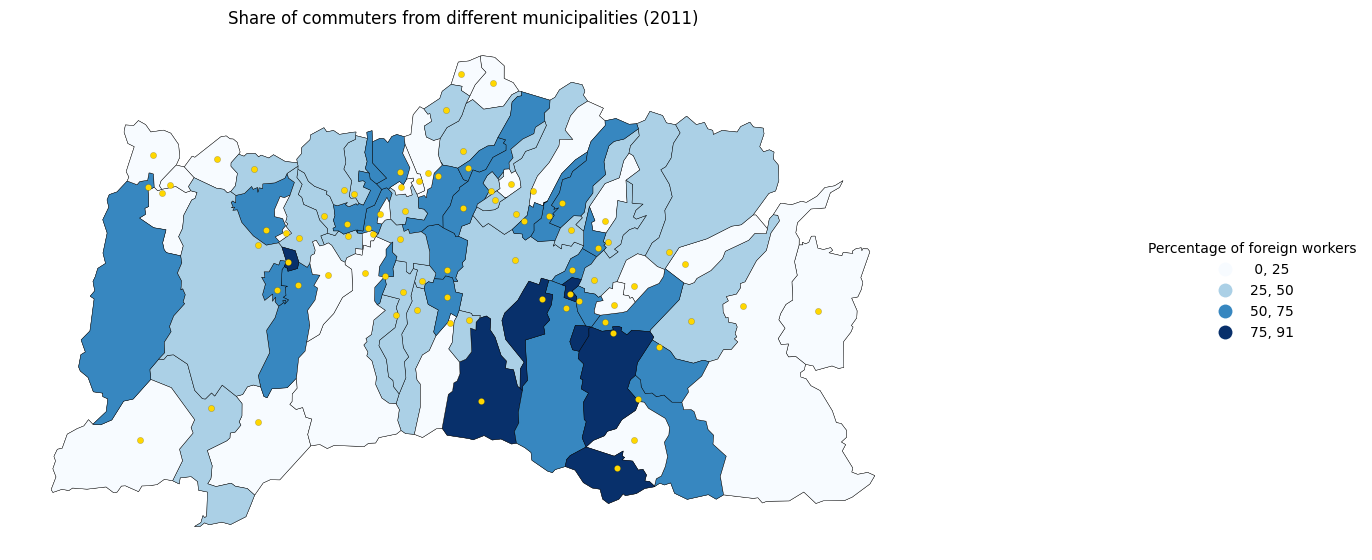

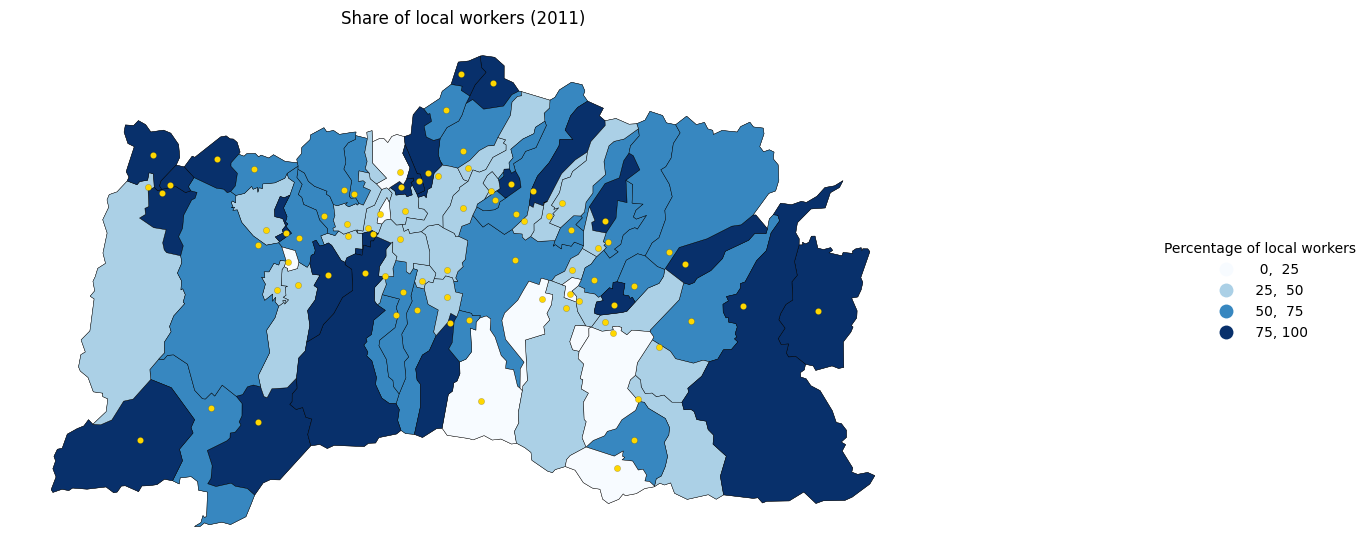

In [6]:
# -------------------------------------------------Share of foreign workers--------------------------------------------------------------

tablemap11 = map2.merge(
    table11,
    left_on = "IDN4",
    right_on = "obecB",
    how = "left"
)

independence_bins = [25, 50, 75]
plt.figure(figsize = (11.69, 8.27))
map2.plot(
    ax = plt.gca(),
    color = "lightgray",
    edgecolor = "black",
    linewidth = 0.3
)
tablemap11.plot(
    ax = plt.gca(),
    column = "mimo_percent11",
    cmap = "Blues",
    legend = True,
    edgecolor = "black",
    linewidth = 0.3,
    scheme = "user_defined",
    classification_kwds = {"bins": independence_bins},
    legend_kwds = {
        "title": "Percentage of foreign workers",
        "loc": "right",
        "fmt": "{:.0f}",
        "frameon": False,
        "bbox_to_anchor": (1.5, 0.5)
    }
)
obce_gdf.plot(
    ax = plt.gca(),
    color = "gold",
    markersize = 20.0,
    edgecolor = "black",
    linewidth = 0.1
)
plt.title("Share of commuters from different municipalities (2011)")
plt.axis(False)
# plt.savefig("../result_maps/workers/LM_RK_foreign_workers_2011.pdf", format = "pdf", dpi = 300, bbox_inches = "tight")
plt.show()
# -------------------------------------------------Share of local workers--------------------------------------------------------------

independence_bins = [25, 50, 75]
plt.figure(figsize = (11.69, 8.27))
map2.plot(
    ax = plt.gca(),
    color = "lightgray",
    edgecolor = "black",
    linewidth = 0.3
)
tablemap11.plot(
    ax = plt.gca(),
    column = "vnutri_percent11",
    cmap = "Blues",
    legend = True,
    edgecolor = "black",
    linewidth = 0.3,
    scheme = "user_defined",
    classification_kwds = {"bins": independence_bins},
    legend_kwds = {
        "title": "Percentage of local workers",
        "loc": "right",
        "fmt": "{:.0f}",
        "frameon": False,
        "bbox_to_anchor": (1.5, 0.5)
    }
)
obce_gdf.plot(
    ax = plt.gca(),
    color = "gold",
    markersize = 20.0,
    edgecolor = "black",
    linewidth = 0.1
)
plt.title("Share of local workers (2011)")
plt.axis(False)
# plt.savefig("../result_maps/workers/LM_RK_local_workers_2011.pdf", format = "pdf", dpi = 300, bbox_inches = "tight")
plt.show()

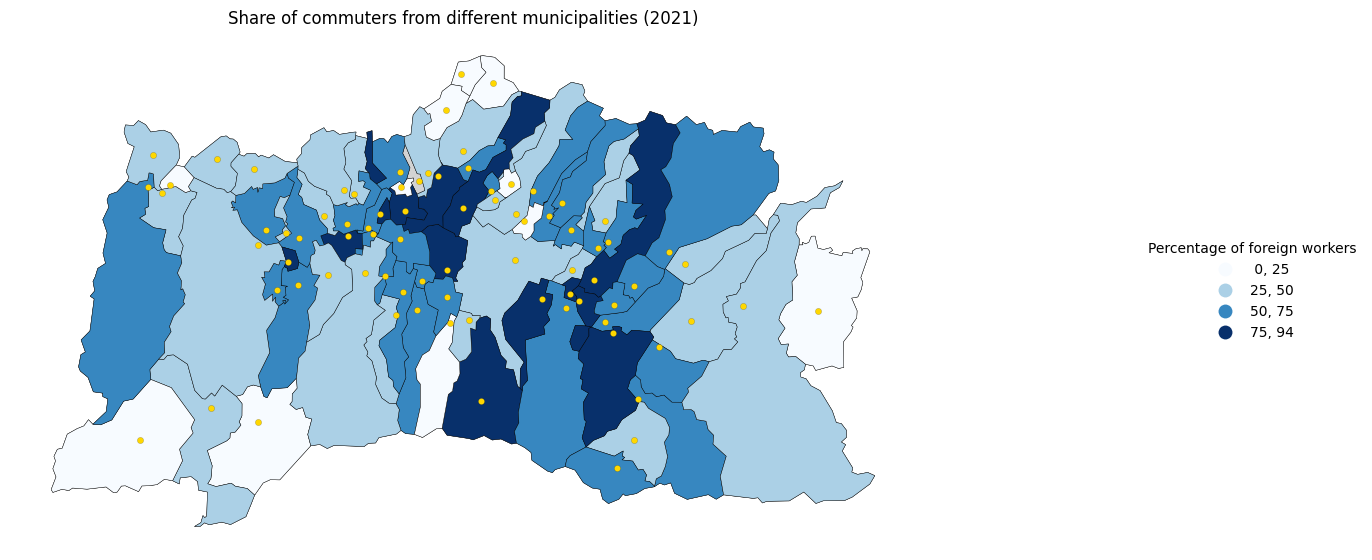

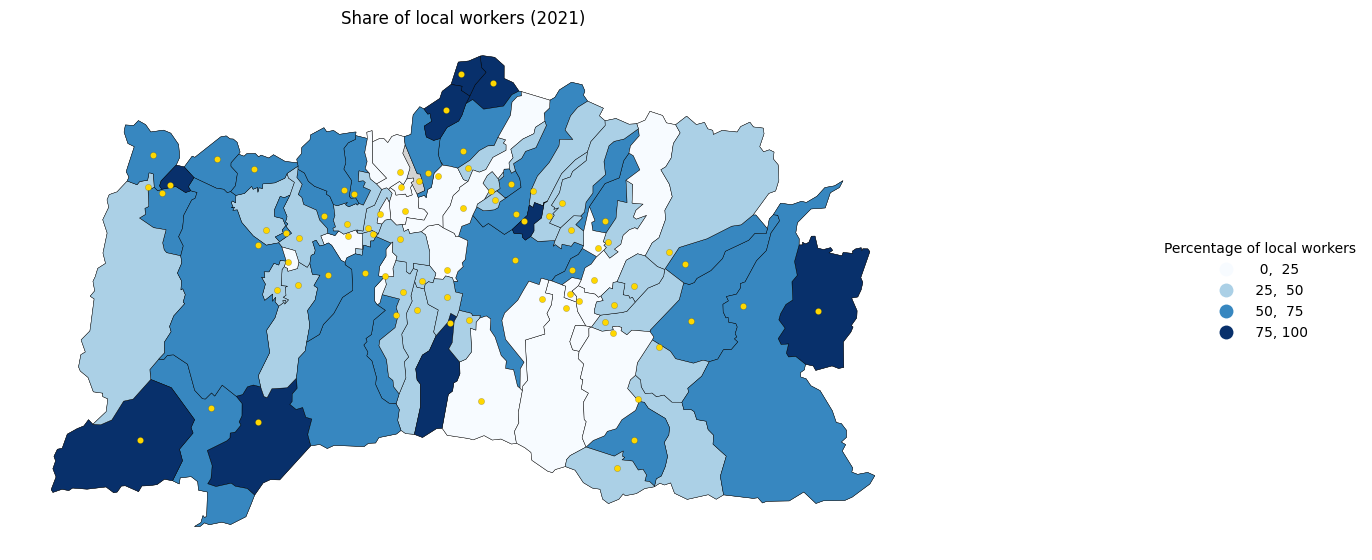

In [7]:
# -------------------------------------------------Share of foreign workers--------------------------------------------------------------

tablemap21 = map2.merge(
    table21,
    left_on = "IDN4",
    right_on = "obecB",
    how = "left"
)

independence_bins = [25, 50, 75]
plt.figure(figsize = (11.69, 8.27))
map2.plot(
    ax = plt.gca(),
    color = "lightgray",
    edgecolor = "black",
    linewidth = 0.3
)
tablemap21.plot(
    ax = plt.gca(),
    column = "mimo_percent21",
    cmap = "Blues",
    legend = True,
    edgecolor = "black",
    linewidth = 0.3,
    scheme = "user_defined",
    classification_kwds = {"bins": independence_bins},
    legend_kwds = {
        "title": "Percentage of foreign workers",
        "loc": "right",
        "fmt": "{:.0f}",
        "frameon": False,
        "bbox_to_anchor": (1.5, 0.5)
    }
)
obce_gdf.plot(
    ax = plt.gca(),
    color = "gold",
    markersize = 20.0,
    edgecolor = "black",
    linewidth = 0.1
)
plt.title("Share of commuters from different municipalities (2021)")
plt.axis(False)
# plt.savefig("../result_maps/workers/LM_RK_foreign_workers_2021.pdf", format = "pdf", dpi = 300, bbox_inches = "tight")
plt.show()
# -------------------------------------------------Share of local workers--------------------------------------------------------------

independence_bins = [25, 50, 75]
plt.figure(figsize = (11.69, 8.27))
map2.plot(
    ax = plt.gca(),
    color = "lightgray",
    edgecolor = "black",
    linewidth = 0.3
)
tablemap21.plot(
    ax = plt.gca(),
    column = "vnutri_percent21",
    cmap = "Blues",
    legend = True,
    edgecolor = "black",
    linewidth = 0.3,
    scheme = "user_defined",
    classification_kwds = {"bins": independence_bins},
    legend_kwds = {
        "title": "Percentage of local workers",
        "loc": "right",
        "fmt": "{:.0f}",
        "frameon": False,
        "bbox_to_anchor": (1.5, 0.5)
    }
)
obce_gdf.plot(
    ax = plt.gca(),
    color = "gold",
    markersize = 20.0,
    edgecolor = "black",
    linewidth = 0.1
)
plt.title("Share of local workers (2021)")
plt.axis(False)
# plt.savefig("../result_maps/workers/LM_RK_local_workers_2021.pdf", format = "pdf", dpi = 300, bbox_inches = "tight")
plt.show()

In [18]:
print(table01["spolu01"].max(), table01["spolu01"].min())
print(table11["spolu11"].max(), table11["spolu11"].min())
print(table21["spolu21"].max(), table21["spolu21"].min())

15750 1
10740 1
9277 1


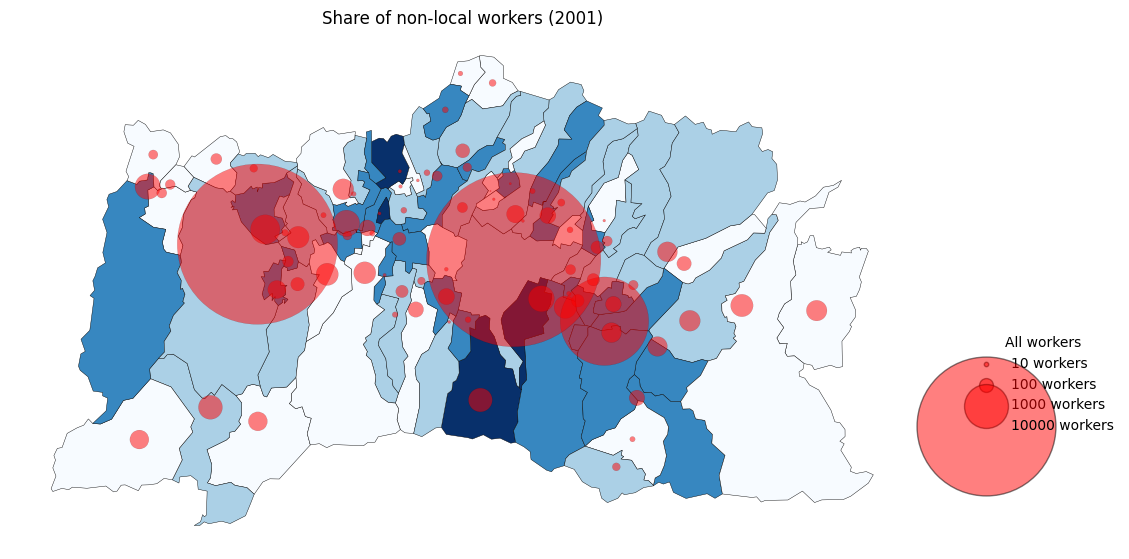

In [26]:
obce_gdf_01 = obce_gdf.merge(
    table01,
    left_on = "kod",
    right_on = "obecB",
    how = "left"
).drop(columns = ["kod_obce", "okMesto", "kMesto", "IDN3", "NM3", "IDN2", "NM2", "NAZOVOBCE", "KODOBCE", "obyv"])
independence_bins = [25, 50, 75]

def scale_size(value, scale = 1):
    return value*scale


# plt.figure(figsize = (11.69, 8.27))
fig, ax = plt.subplots(figsize = (11.67, 8.27))
choropleth = tablemap01.plot(
    ax = ax,
    column = "mimo_percent01",
    cmap = "Blues",
    legend = True,
    edgecolor = "black",
    linewidth = 0.3,
    scheme = "user_defined",
    classification_kwds = {"bins": independence_bins},
    legend_kwds = {
        "title": "Percentage of foreign workers",
        "loc": "right",
        "fmt": "{:.0f}",
        "frameon": False,
        "bbox_to_anchor": (1.5, 0.5)
    }
)
obce_gdf_01["markersize01"] = obce_gdf_01["spolu01"].apply(scale_size)
obce_gdf_01.plot(
    ax = ax,
    color = "red",
    markersize = obce_gdf_01["markersize01"],
    alpha = 0.5,
    edgecolor = "black",
    linewidth = 0.1
)
circle_size = [10, 100, 1000, 10000]
legend_circles = [
    plt.scatter([], [], s = scale_size(val), color = "red", alpha = 0.5, edgecolor = "black", label = f"{val} workers")
    for val in circle_size
]

legend1 = ax.legend(
    handles = legend_circles,
    title = "All workers",
    loc = "lower left",
    bbox_to_anchor = (1.05, 0.2),
    frameon = False
)

plt.title("Share of non-local workers (2001)")
plt.axis(False)
# plt.savefig("../result_maps/autonomy/LM_RK_autonomy_2001_binary.pdf", format = "pdf", dpi = 300, bbox_inches = "tight")
plt.show()

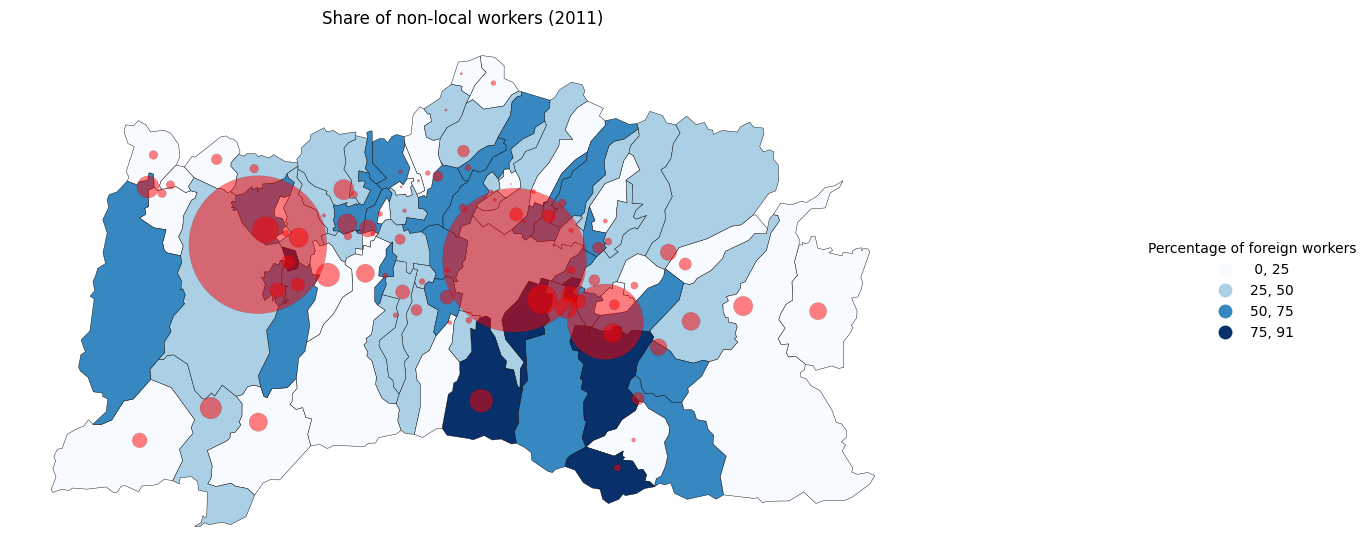

In [11]:
obce_gdf_11 = obce_gdf.merge(
    table11,
    left_on = "kod",
    right_on = "obecB",
    how = "left"
).drop(columns = ["kod_obce", "okMesto", "kMesto", "IDN3", "NM3", "IDN2", "NM2", "NAZOVOBCE", "KODOBCE", "obyv"])
independence_bins = [25, 50, 75]
plt.figure(figsize = (11.69, 8.27))
# tablemap01.plot(
#     ax = plt.gca(),
#     cmap = "blues",
#     edgecolor = "black",
#     linewidth = 0.3
# )
tablemap11.plot(
    ax = plt.gca(),
    column = "mimo_percent11",
    cmap = "Blues",
    legend = True,
    edgecolor = "black",
    linewidth = 0.3,
    scheme = "user_defined",
    classification_kwds = {"bins": independence_bins},
    legend_kwds = {
        "title": "Percentage of foreign workers",
        "loc": "right",
        "fmt": "{:.0f}",
        "frameon": False,
        "bbox_to_anchor": (1.5, 0.5)
    }
)
obce_gdf.plot(
    ax = plt.gca(),
    color = "red",
    markersize = obce_gdf_11["spolu11"],
    alpha = 0.5,
    edgecolor = "black",
    linewidth = 0.1
)

# handles_i = [
#     plt.Line2D(
#         [0], [0],
#         marker = "s",
#         markersize = 10,
#         linestyle = "None",
#         color = color,
#         # edgecolor = "black",
#         label = ">50 per cent in municipality" if key else ">50 per cent outside municipality"
#         )
#         for key, color in color_dict_i.items()
# ]
# handles_i.append(
#     plt.Line2D(
#         [0], [0],
#         marker = "",
#         color = "white",
#         markersize = 20,
#         linestyle = "None",
#         label = ""
#     )
# )
# handles_i.append(
#     plt.Line2D(
#         [0], [0],
#         marker = "o",
#         color = "blue",
#         alpha = 0.5,
#         markersize = 20,
#         linestyle = "None",
#         label = "municipality (size represents amount of people\nworking in municipality)"
#     )
# )
# plt.legend(
#     handles = handles_i,
#     title = "Do people commute outside of municipality",
#     loc = "center left",
#     bbox_to_anchor = (1, 0.5),
#     frameon = False
# )

plt.title("Share of non-local workers (2011)")
plt.axis(False)
# plt.savefig("../result_maps/autonomy/LM_RK_autonomy_2011_binary.pdf", format = "pdf", dpi = 300, bbox_inches = "tight")
plt.show()

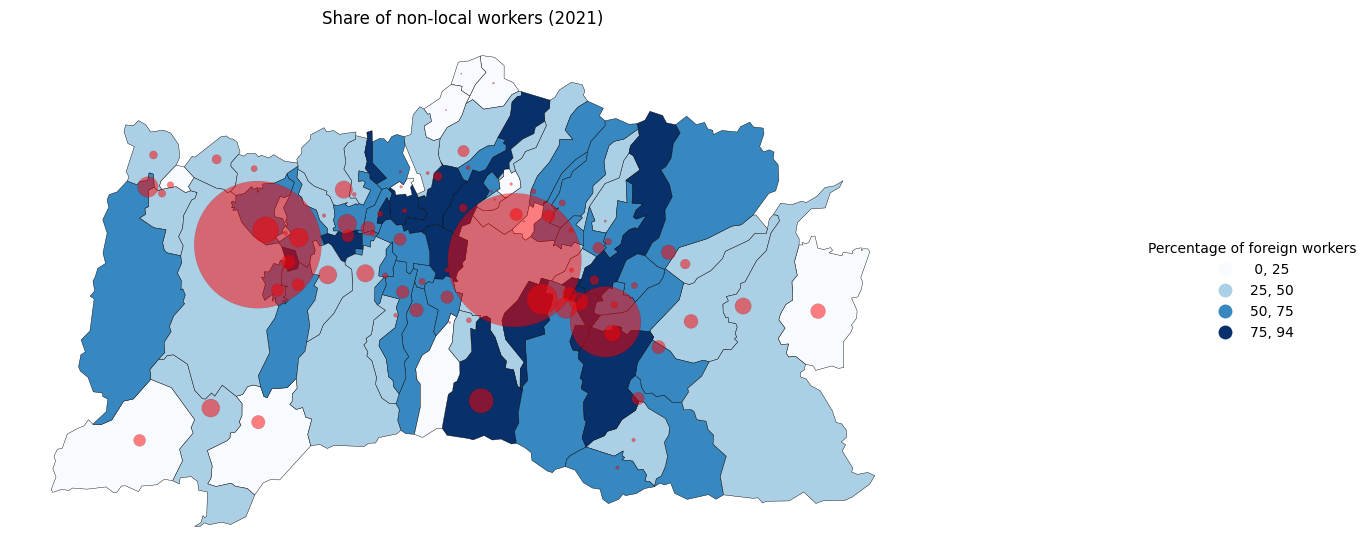

In [12]:
obce_gdf_21 = obce_gdf.merge(
    table21,
    left_on = "kod",
    right_on = "obecB",
    how = "left"
).drop(columns = ["kod_obce", "okMesto", "kMesto", "IDN3", "NM3", "IDN2", "NM2", "NAZOVOBCE", "KODOBCE", "obyv"])
independence_bins = [25, 50, 75]
plt.figure(figsize = (11.69, 8.27))
# tablemap21.plot(
#     ax = plt.gca(),
#     cmap = "blues",
#     edgecolor = "black",
#     linewidth = 0.3
# )
tablemap21.plot(
    ax = plt.gca(),
    column = "mimo_percent21",
    cmap = "Blues",
    legend = True,
    edgecolor = "black",
    linewidth = 0.3,
    scheme = "user_defined",
    classification_kwds = {"bins": independence_bins},
    legend_kwds = {
        "title": "Percentage of foreign workers",
        "loc": "right",
        "fmt": "{:.0f}",
        "frameon": False,
        "bbox_to_anchor": (1.5, 0.5)
    }
)
obce_gdf.plot(
    ax = plt.gca(),
    color = "red",
    markersize = obce_gdf_21["spolu21"],
    alpha = 0.5,
    edgecolor = "black",
    linewidth = 0.1
)

# handles_i = [
#     plt.Line2D(
#         [0], [0],
#         marker = "s",
#         markersize = 10,
#         linestyle = "None",
#         color = color,
#         # edgecolor = "black",
#         label = ">50 per cent in municipality" if key else ">50 per cent outside municipality"
#         )
#         for key, color in color_dict_i.items()
# ]
# handles_i.append(
#     plt.Line2D(
#         [0], [0],
#         marker = "",
#         color = "white",
#         markersize = 20,
#         linestyle = "None",
#         label = ""
#     )
# )
# handles_i.append(
#     plt.Line2D(
#         [0], [0],
#         marker = "o",
#         color = "blue",
#         alpha = 0.5,
#         markersize = 20,
#         linestyle = "None",
#         label = "municipality (size represents amount of people\nworking in municipality)"
#     )
# )
# plt.legend(
#     handles = handles_i,
#     title = "Do people commute outside of municipality",
#     loc = "center left",
#     bbox_to_anchor = (1, 0.5),
#     frameon = False
# )

plt.title("Share of non-local workers (2021)")
plt.axis(False)
# plt.savefig("../result_maps/autonomy/LM_RK_autonomy_2021_binary.pdf", format = "pdf", dpi = 300, bbox_inches = "tight")
plt.show()